## Primero importaré pandas y exportaré la base de datos

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

df# Your code here

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


## Procedo a eliminar columnas basura para limpiar mi base de datos

In [2]:
df = df.drop(['transaction_id', 'user_id'], axis=1)

## Procedemos a realizar el EDA

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   str    
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   str    
 11  academic_work_impact     7500 non-null   str    
 12  addiction_level          6681 non-null   str    
 13  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(4), str(4)
mem

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


## Mi variable objetivo será ADDICTED_LABEL, debido a que puedo clasificar en adictos o no adictos y es idela para aplicaciones prácticas y facilita la integración del modelo en una aplicación web. Así que tengo que limpiar mi DATASET.

In [4]:
y = df['addicted_label']

## Eliminaré la columna Addiction_level, porque no será la base de mi modelo y me puede generar problemas

In [5]:
df = df.drop('addiction_level', axis=1)

df = pd.get_dummies(df, drop_first=True)

X = df

list(X.columns)

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'addicted_label',
 'gender_Male',
 'gender_Other',
 'stress_level_Low',
 'stress_level_Medium',
 'academic_work_impact_Yes']

## Ahora que ya tengo limpio mi DATASET y procedo a ver la distribuición de los datos conforme a la cantidad de "0" y ver que las variables sean adecuadas

In [6]:
cols = ['age', 'daily_screen_time_hours','social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender_Male',
 'gender_Other',
 'stress_level_Low',
 'stress_level_Medium',
 'academic_work_impact_Yes']

(df[cols] == 0).sum()

age                            0
daily_screen_time_hours        0
social_media_hours             0
gaming_hours                   6
work_study_hours               0
sleep_hours                    0
notifications_per_day          0
app_opens_per_day              0
weekend_screen_time            0
gender_Male                 4947
gender_Other                5014
stress_level_Low            4997
stress_level_Medium         5063
academic_work_impact_Yes    3753
dtype: int64

## Este análisis confirma que el dataset está correctamente codificado, sin valores anómalos críticos, y es adecuado para el entrenamiento de modelos de machine learning. Ahora haré un análisis de correlación.

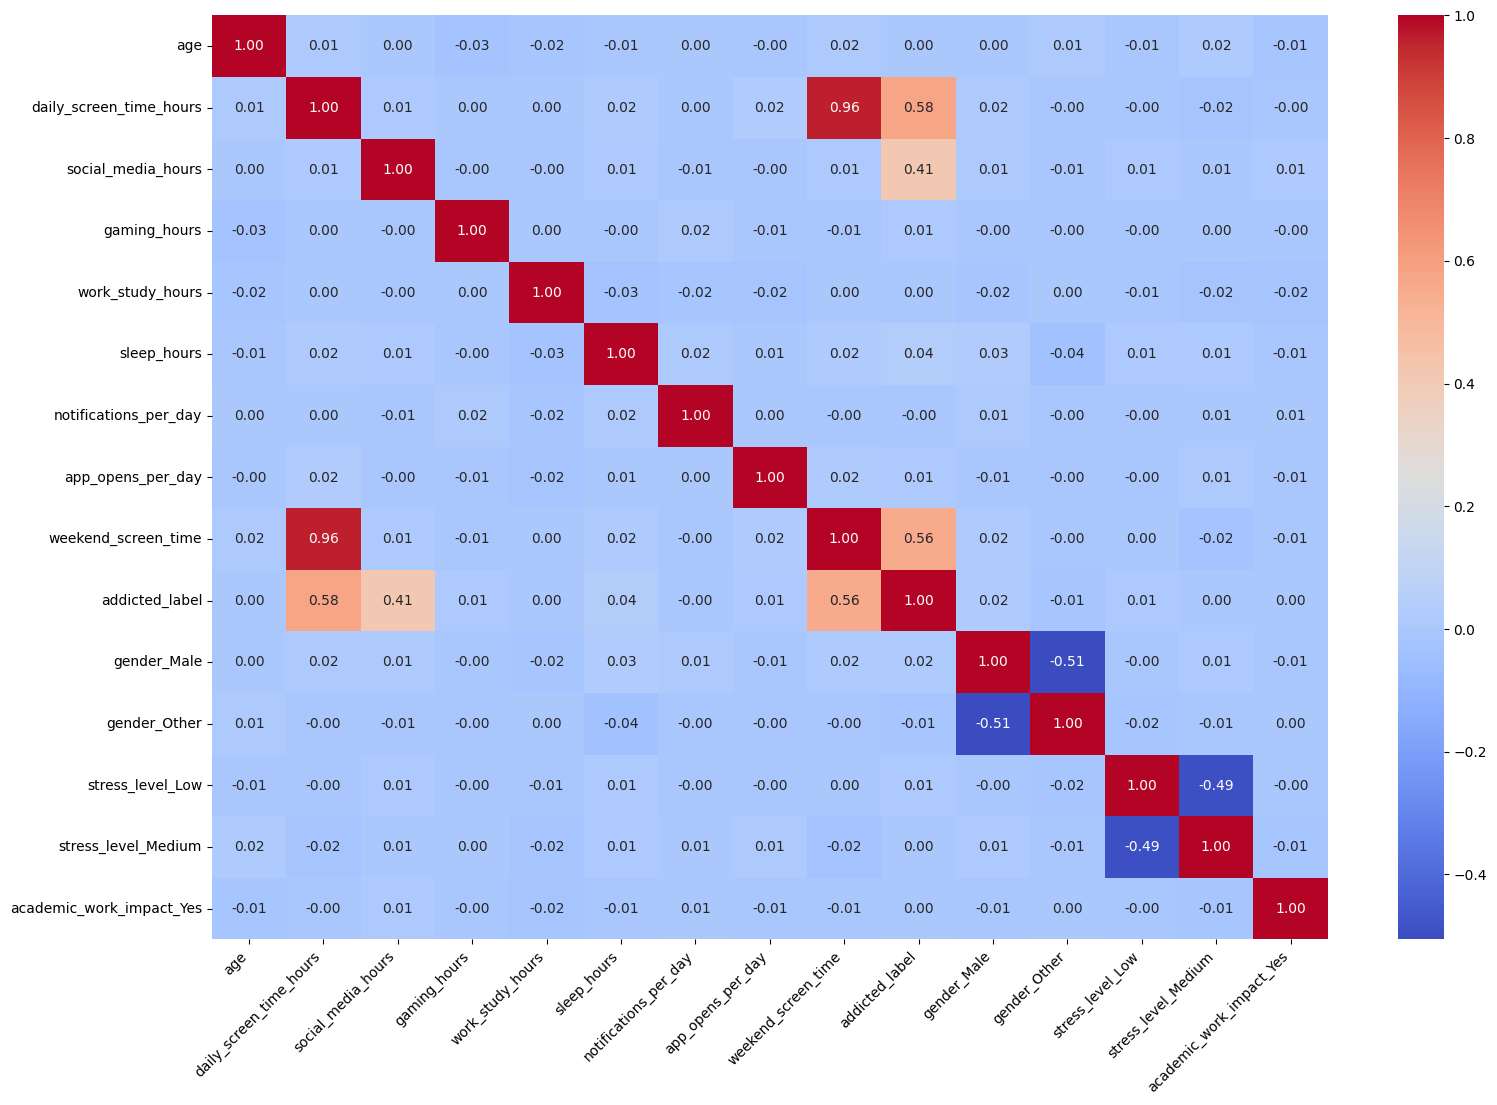

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

## Este mapa de calor nos arroja que la mayoría de las variables tienen relaciones débiles entre sí, lo cual indica que aportan información independiente al modelo.

## La relación más fuerte se observa entre el uso diario del dispositivo y el uso en fines de semana (0.96), lo que refleja un patrón consistente de comportamiento en los usuarios.

In [8]:
df.corr()['addicted_label'].sort_values(ascending=False)

addicted_label              1.000000
daily_screen_time_hours     0.577112
weekend_screen_time         0.555426
social_media_hours          0.414244
sleep_hours                 0.035496
gender_Male                 0.022989
app_opens_per_day           0.011041
gaming_hours                0.008485
stress_level_Low            0.006555
age                         0.004220
work_study_hours            0.001103
stress_level_Medium         0.000159
academic_work_impact_Yes    0.000072
notifications_per_day      -0.000660
gender_Other               -0.014589
Name: addicted_label, dtype: float64

## Para confirmarlo se ordenaron las variables según su correlación con la variable objetivo para identificar los predictores más relevantes. Por lo que ahora procedemos a visualizar las relaciones clave

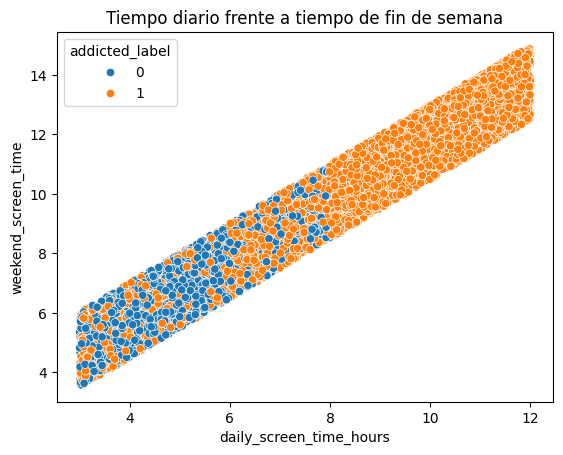

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['daily_screen_time_hours'], y=df['weekend_screen_time'], hue=df['addicted_label'])
plt.title("Tiempo diario frente a tiempo de fin de semana")
plt.show()

## Los usuarios con mayor tiempo de uso diario del teléfono también presentan mayor uso durante fines de semana, y este comportamiento está fuertemente asociado con la etiqueta de adicción.

## Ahora procedemos a separar el dataset en variables independientes

In [10]:
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

## Ahora haremos nuestro modelo

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.info()

<class 'pandas.DataFrame'>
Index: 6000 entries, 4664 to 7270
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       6000 non-null   int64  
 1   daily_screen_time_hours   6000 non-null   float64
 2   social_media_hours        6000 non-null   float64
 3   gaming_hours              6000 non-null   float64
 4   work_study_hours          6000 non-null   float64
 5   sleep_hours               6000 non-null   float64
 6   notifications_per_day     6000 non-null   int64  
 7   app_opens_per_day         6000 non-null   int64  
 8   weekend_screen_time       6000 non-null   float64
 9   gender_Male               6000 non-null   bool   
 10  gender_Other              6000 non-null   bool   
 11  stress_level_Low          6000 non-null   bool   
 12  stress_level_Medium       6000 non-null   bool   
 13  academic_work_impact_Yes  6000 non-null   bool   
dtypes: bool(5), float64(6

## Utilizaré XG BOOST como modelo por la precisión de datos que requiero

In [12]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [13]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [14]:
from xgboost import XGBClassifier  

model = XGBClassifier(random_state=42)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Ahora que ya tengo un modelo voy a predecir su eficiencia

In [15]:
y_pred_xgb = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_xgb)

0.9226666666666666

## Mi predicción arroja un 92.26% de efectividad. Ahora explicaremos este modelo

In [16]:
resultados = []

for i in range (1, 50):
    model_xgb = XGBClassifier(random_state=42, n_estimators=i)
    model_xgb.fit(X_train, y_train)
    y_pred = model_xgb.predict(X_test)
    print (f'modelo {i} listo')
    resultados.append((i, accuracy_score(y_test, y_pred)))
best_accuracy = 0
i=0
resultados_m = []

for resultado in resultados:
    resultados_m.append(resultado[1])
    if resultado[1] > best_accuracy:
        best_accuracy = resultado[1]
    i = resultado[0]
print (f'El mejor resultado es con n_estimators: {i} y una accuracy es de: {best_accuracy}')

modelo 1 listo
modelo 2 listo
modelo 3 listo
modelo 4 listo
modelo 5 listo
modelo 6 listo
modelo 7 listo
modelo 8 listo
modelo 9 listo
modelo 10 listo
modelo 11 listo
modelo 12 listo
modelo 13 listo
modelo 14 listo
modelo 15 listo
modelo 16 listo
modelo 17 listo
modelo 18 listo
modelo 19 listo
modelo 20 listo
modelo 21 listo
modelo 22 listo
modelo 23 listo
modelo 24 listo
modelo 25 listo
modelo 26 listo
modelo 27 listo
modelo 28 listo
modelo 29 listo
modelo 30 listo
modelo 31 listo
modelo 32 listo
modelo 33 listo
modelo 34 listo
modelo 35 listo
modelo 36 listo
modelo 37 listo
modelo 38 listo
modelo 39 listo
modelo 40 listo
modelo 41 listo
modelo 42 listo
modelo 43 listo
modelo 44 listo
modelo 45 listo
modelo 46 listo
modelo 47 listo
modelo 48 listo
modelo 49 listo
El mejor resultado es con n_estimators: 49 y una accuracy es de: 0.936


## El resultado nos dio que el mejor resultado es con: n_estimators 49 y ahora el accuracy subió a 93.6%

## Ahora vamos a graficar

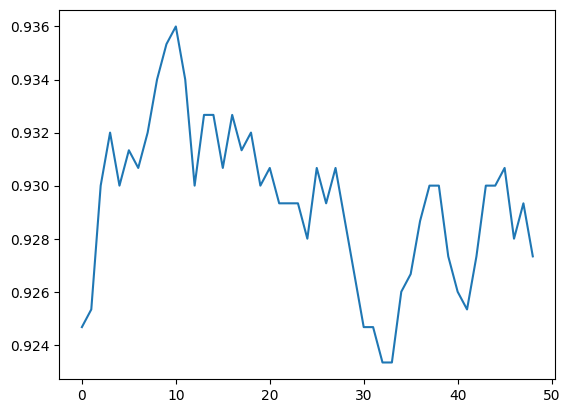

In [17]:
import matplotlib.pyplot as plt

plt.plot(resultados_m)
plt.show()

## Aqui podemos verificar la precisión del modelo y procedemos a guardarlo

In [18]:
from pickle import dump

dump(model, open("../models/Smarthphone_addiction_XG_Boost.sav", "wb"))

## AHORA EMPEZAREMOS CON LA APOLICACIÓN DE FLASK